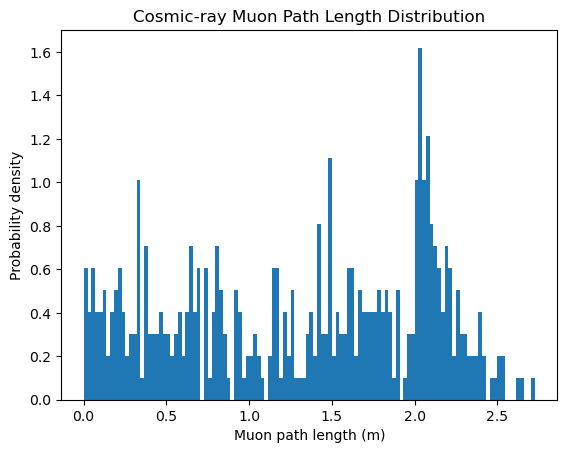

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Detector geometry
# ----------------------------
R = 1.0
Rwide = 10.0
H = 2.0
a = 1.3
N = 100_000  # easily scalable to 10M+

# ----------------------------
# Entry points (top surface)
# ----------------------------
r = Rwide * np.sqrt(np.random.rand(N))
phi = 2*np.pi*np.random.rand(N)

x0 = r*np.cos(phi)
y0 = r*np.sin(phi)
z0 = np.full(N, H/2)

# ----------------------------
# Cosmic-ray angular distribution
# approx cos^2(theta)
# ----------------------------
theta = np.arccos(np.random.rand(N))
phi_dir = 2*np.pi*np.random.rand(N)

accept = np.random.rand(N) < np.power(np.cos(theta),a)
theta = theta[accept]
phi_dir = phi_dir[accept]

x0 = x0[accept]
y0 = y0[accept]
z0 = z0[accept]

# direction vectors
vx = np.sin(theta)*np.cos(phi_dir)
vy = np.sin(theta)*np.sin(phi_dir)
vz = -np.cos(theta)

# ----------------------------
# Cylinder wall intersection
# ----------------------------
a = vx**2 + vy**2
b = 2*(x0*vx + y0*vy)
c = x0**2 + y0**2 - R**2

disc = b**2 - 4*a*c
disc[disc < 0] = np.nan

t1 = (-b + np.sqrt(disc))/(2*a)
t2 = (-b - np.sqrt(disc))/(2*a)


#make vector for muons hitting INSIDE R
cIn = (r[accept]<=R)
t1_in = t1[~np.isnan(t1)&(cIn)]
t2_in = t2[~np.isnan(t2)&(cIn)]

#print(np.min(t1_out*t2_out))
#print(np.max(t1_in*t2_in))
#print(np.min(t1_out),np.max(t1_out))
#print(np.min(t2_out),np.max(t2_out))

# keep forward solutions
#t_side = np.where((t1 > 0) & (t1 < t2), t1, t2)
t_side_in = np.where((t1_in > 0), t1_in, t2_in)


# ----------------------------
# Bottom cap intersection
# ----------------------------
t_bottom_in = (-H/2 - z0[cIn])/vz[cIn]
t_bottom_in[t_bottom_in <= 0] = np.nan


# ----------------------------
# Choose first exit
# ----------------------------
t_exit_in = np.nanmin(np.vstack([t_side_in, t_bottom_in]), axis=0)

# path lengths

#vnorm = np.sqrt(vx**2 + vy**2 + vz**2)

lengths_in = t_exit_in

# remove NaNs
lengths_in = lengths_in[np.isfinite(lengths_in)]


#make vector for muons hitting OUTSIDE R
t1_out = t1[~np.isnan(t1)&(~cIn)&(t1>0)]
t2_out = t2[~np.isnan(t2)&(~cIn)&(t1>0)]

x0_out = x0[~np.isnan(t1)&(~cIn)&(t1>0)]
y0_out = y0[~np.isnan(t1)&(~cIn)&(t1>0)]
vx_out = vx[~np.isnan(t1)&(~cIn)&(t1>0)]
vy_out = vy[~np.isnan(t1)&(~cIn)&(t1>0)]
vz_out = vz[~np.isnan(t1)&(~cIn)&(t1>0)]

h_out = t2_out*np.abs(vz_out)
s1 = H - t1_out*np.abs(vz_out)
#s2 = np.sqrt((t1_out*vx_out - )**2 + ()**2)

#t_side_out = np.where((h_out<=H),t2_out-t1_out,xx)


# ----------------------------
# Histogram
# ----------------------------
plt.hist(lengths_in, bins=120, density=True)
plt.yscale('linear')
plt.xlabel("Muon path length (m)")
plt.ylabel("Probability density")
plt.title("Cosmic-ray Muon Path Length Distribution")
plt.show()